# Case Study 2:
### Goals for notebook
- Labels = Days before game customer purchased

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from os import path 

import dotenv as de

from scipy.stats import pearsonr

# Load Data + Initial Exploration

In [37]:
DATASET_NAME = de.get_key(".env", "DATASET_NAME")

data = pd.read_excel(f"data/{DATASET_NAME}", sheet_name = [1,2]) #Load in the 2nd and 3rd sheets of the excel file (all other sheets contain metadata and are not relevant)

In [38]:
DATA_ORIGINAL = pd.concat([data[1], data[2]], axis=0, ignore_index=True)

In [39]:
def preprocess_dataframe(df_orig):
    df = df_orig.copy()
    df['Fan_Mailing_List'] = df['Fan_Mailing_List'].map({"Yes" : 1, "No" : 0}).astype(bool)
    df['Seat_Is_Upper'] = df['Seat_Location'].map({"Upper" : 1, "Lower" : 0}).astype(bool)

    df['Days_Before_Game'] = df['Days_Before_Game'].astype("float64")

    return df 

DATA = preprocess_dataframe(DATA_ORIGINAL)

In [40]:
#DATA.shape

# EDA

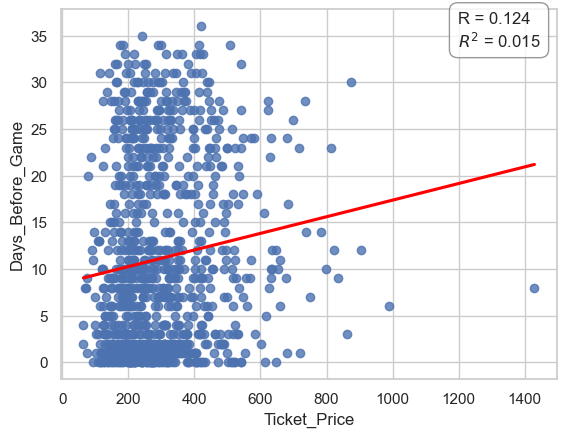

In [41]:
x = DATA['Ticket_Price']
y = DATA['Days_Before_Game']
r_value, _ = pearsonr(x, y)
r2_value = r_value**2

sns.set_theme(style="whitegrid")
ax = sns.regplot(x=x, y=y, ci=None, line_kws={"color" : "red"})
stats_text = f"R = {r_value:0.3f}\n$R^2$ = {r2_value:0.3f}"
plt.text(
    0.8, 0.9, stats_text,
    transform=ax.transAxes,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5')
)
plt.show()

### Does being on the mailing list influence the number of dates out the ticket purchase.

<Axes: xlabel='Fan_Mailing_List', ylabel='Days_Before_Game'>

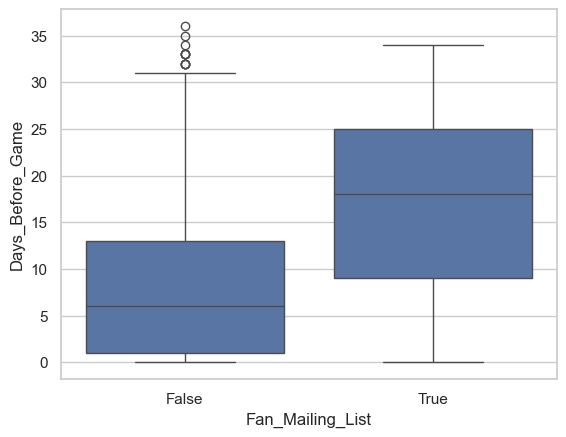

In [42]:
x = DATA['Fan_Mailing_List']
y = DATA['Days_Before_Game']
sns.boxplot(x=x, y=y)

**Remark:** On average, being on the mailing list on average causes patrons to purchase their tickets further out.

<Axes: xlabel='Seat_Is_Upper', ylabel='Days_Before_Game'>

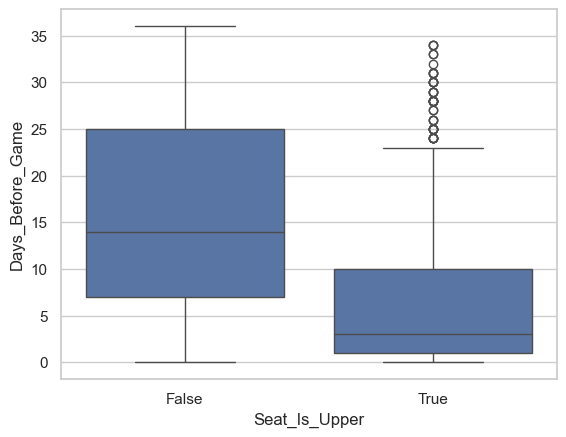

In [43]:
x = DATA['Seat_Is_Upper']
y = DATA['Days_Before_Game']
sns.boxplot(x=x, y=y)

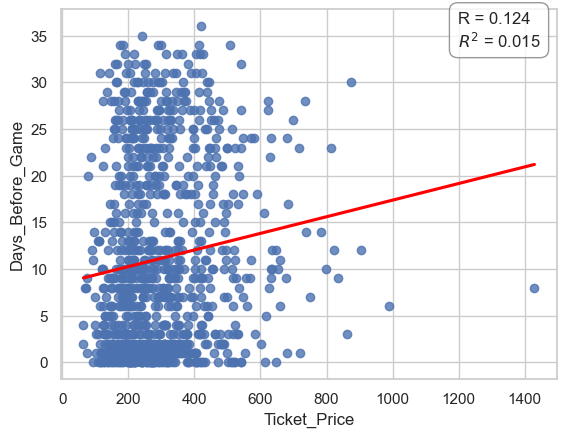

In [44]:
x = DATA['Ticket_Price']
y = DATA['Days_Before_Game']

r_value, _ = pearsonr(x, y)
r2_value = r_value**2

sns.set_theme(style="whitegrid")
ax = sns.regplot(x=x, y=y, ci=None, line_kws={"color" : "red"})
stats_text = f"R = {r_value:0.3f}\n$R^2$ = {r2_value:0.3f}"
plt.text(
    0.8, 0.9, stats_text,
    transform=ax.transAxes,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5')
)
plt.show()

Text(0, 0.5, 'Number of tickets sold')

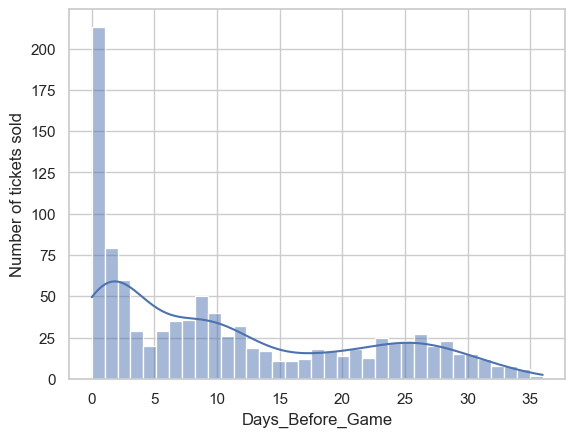

In [45]:
#TODO: Group by gameID and see what the distribution looks like.

x = DATA['Days_Before_Game']
axs = sns.histplot(x=x, bins=35, kde=True)
axs.set_ylabel("Number of tickets sold")

### What is the distribution of days_before_game vs what category they fall under?

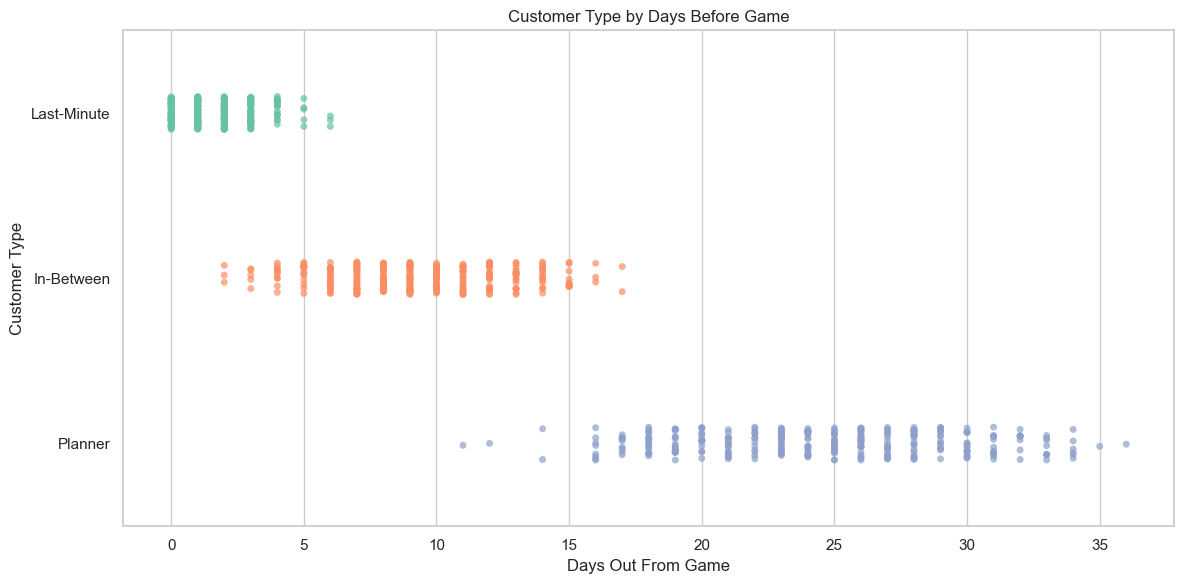

In [46]:
plt.figure(figsize=(12, 6))

sns.stripplot(
    data=DATA,
    x="Days_Before_Game",
    y="Customer_Type",
    hue="Customer_Type",
    jitter=True,
    alpha=0.7,
    palette="Set2",
    legend=False
)

plt.xlabel("Days Out From Game")
plt.ylabel("Customer Type")
plt.title("Customer Type by Days Before Game")
plt.tight_layout()
plt.show()

Multi-Task Learning helps learn around the boundaries. Especially since this is not a clear split.  This was a clear challenge to my hypothesis where I though the labels would be able to be easily binned.

### How many tickets are being sold on average?

In [47]:
#TODO Groupby game id and count the number of seats on average. BUG: THIS IS BROKEN.

num_seats_per_game = DATA[['customerID', 'Game_ID']].groupby('Game_ID').count().sort_values(by='customerID', ascending=False)
#display(num_seats_per_game.head())